# Cell 1: Import everything:


In [16]:
import torch
import numpy as np

from sklearn.model_selection import train_test_split
from transformers import BertModel, BertConfig
from torch.utils.data import DataLoader

# Data handeling
from src.data.dataset import MLMDataset, ClassificationDataset, HieraricalClassificationDataset
from src.data.data_tools import filter_taxonomy, fasta2pandas

#Vocab shit
from src.utils.vocab import Vocabulary, KmerVocabConstructor

# Preprocessing
from src.preprocessing.augmentation import SequenceModifier, IdentityStrategy, BaseStrategy
from src.preprocessing.tokenization import KmerStrategy
from src.preprocessing.padding import PEndStrategy
from src.preprocessing.truncation import TEndStrategy
from src.preprocessing.preprocessor import Preprocessor

# Model things
from src.model.backbone import Bertax, ModularBertax
from src.model.encoders import LabelEncoder
from src.model.heads import MLMHead, SingleClassHead, HierarchicalClassificationHead

# Training things
from src.train.trainers import MLMtrainer, ClassificationTrainer, HierarchicalClassificationTrainer

In [17]:
CONFIG = {
    "FILE_PATH": "src/data/raw.fasta",
    "SAVE_PATH": "pretrained_model.pt",
    "n_test": 1000,
    "modification_probability": 0.05,
    "alphabet": ["A", "C", "G", "T"],
    "k": 3,
    "optimal_length": 200,

    # Training parameters
    "num_epochs": 1,
    "masking_percentage": 0.05,
    "batch_size": 128,
    "small_set": False,

    # Model configuration
    "num_layers": 10,
    "num_attention_heads": 4,
    "hidden_size": 256,
    "intermediate_size": 1024,  # 4 * hidden_size
    "dropout_rate": 0.05,
    "num_classes": 19,
    "mlm_dropout_rate": 0.1,

    #Classification 
    "target_labels": ["phylum", "class", "order"]
}

In [18]:

# Set up vocabulary
constructor = KmerVocabConstructor(k=CONFIG["k"], alphabet=CONFIG["alphabet"])
vocab = Vocabulary()
vocab.build_from_constructor(constructor, data=[])
vocab_path = "vocab.json"
vocab.save(vocab_path)

# Set up preprocessors
sequence_modifier = SequenceModifier(alphabet=CONFIG["alphabet"])
augmentation_strategy_train = BaseStrategy(
    modifier=sequence_modifier,
    alphabet=CONFIG["alphabet"],
    modification_probability=CONFIG["modification_probability"]
)

augmentation_strategy_val = IdentityStrategy(
    modifier=sequence_modifier,
    alphabet=CONFIG["alphabet"],
    modification_probability=0
)

tokenization_strategy = KmerStrategy(
    k=CONFIG["k"],
    padding_alphabet=CONFIG["alphabet"]
)

padding_strategy = PEndStrategy(
    optimal_length=CONFIG["optimal_length"]
)

truncation_strategy = TEndStrategy(
    optimal_length=CONFIG["optimal_length"]
)

preprocessor_train = Preprocessor(
    augmentation_strategy=augmentation_strategy_train,
    tokenization_strategy=tokenization_strategy,
    padding_strategy=padding_strategy,
    truncation_strategy=truncation_strategy,
    vocab=vocab,
)

preprocessor_val = Preprocessor(
    augmentation_strategy=augmentation_strategy_val,
    tokenization_strategy=tokenization_strategy,
    padding_strategy=padding_strategy,
    truncation_strategy=truncation_strategy,
    vocab=vocab,
)



In [19]:

##################################################################
## Data preparation ##############################################
##################################################################

all_data = fasta2pandas(CONFIG["FILE_PATH"])

#tmp: to use a smaller set for test if code compiles - nothing to be used in production
if CONFIG["small_set"]:
    all_data = all_data[:CONFIG["n_test"]]

target_labels = CONFIG["target_labels"]

# filter data for finetuning
filtered_data = filter_taxonomy(
    df = all_data,
    startAt =target_labels[0],
    endAt = target_labels[-1],
    phylumCertainty = True
    )

# 

class_sizes = [len(list(set(filtered_data[target_label]))) for target_label in target_labels]

label_encoders = {}
for target_label in target_labels:
    label_encoders[target_label] = LabelEncoder(list(set(filtered_data[target_label])))
    
# Pretraining datasplit based on unsplit data: 
pretrain_sequences, preval_sequences = train_test_split(
    all_data["sequence"],
    test_size = 0.1,
    random_state = 42
)

# Finetune datasplit based on filtered data:
finetrain_data, fineval_data = train_test_split(
    filtered_data,
    test_size = 0.1,
    random_state = 69
    )

print(f"Number of pre-training sequences: {len(pretrain_sequences)}")
print(f"Number of validation sequences: {len(preval_sequences)}")


Applying filters...
Filtering complete.

Handling DNA ambiguity codes...
Processing row 0...
Processing row 10000...
Processing row 20000...
Processing row 30000...
Processing row 40000...
Processing row 50000...
Processing row 60000...
Processing row 70000...
Processing row 80000...
Processing row 90000...
Processing complete.
Number of pre-training sequences: 83962
Number of validation sequences: 9330


In [20]:
ids = range(9)


for id in ids:
    print("Id", id)
    for target_lvl, label_encoder in label_encoders.items():
        label = all_data[target_lvl][id]
        print(target_lvl, label, label_encoder.encode(label))
    print()

Id 0
phylum Ascomycota 6
class Eurotiomycetes 66
order Verrucariales 36

Id 1
phylum Ascomycota 6
class Dothideomycetes 40
order Stigmatodiscales 255

Id 2
phylum Rozellomycota 16
class Rozellomycota_cls_Incertae_sedis 22
order Rozellomycota_ord_Incertae_sedis 363

Id 3
phylum Basidiomycota 14
class Agaricomycetes 25
order Agaricales 24

Id 4
phylum Basidiomycota 14
class Agaricomycetes 25
order Sebacinales 38

Id 5
phylum Basidiomycota 14
class Agaricomycetes 25
order Sebacinales 38

Id 6
phylum Basidiomycota 14
class Agaricomycetes 25
order Thelephorales 195

Id 7
phylum Fungi_phy_Incertae_sedis None
class Fungi_cls_Incertae_sedis None
order Fungi_ord_Incertae_sedis None

Id 8
phylum Basidiomycota 14
class Agaricomycetes 25
order Corticiales 63



In [21]:
print(label_encoders)

{'phylum': <src.model.encoders.LabelEncoder object at 0x000001E169D30710>, 'class': <src.model.encoders.LabelEncoder object at 0x000001E169D313D0>, 'order': <src.model.encoders.LabelEncoder object at 0x000001E16E7CD760>}


In [22]:
##################################################################
## Setup Datasets ################################################
##################################################################

# Pretraining datasets
pretrain_dataset = MLMDataset(
    df = pretrain_sequences,
    preprocessor = preprocessor_train,
    masking_percentage = CONFIG["masking_percentage"]
)

preval_dataset = MLMDataset(
    df = preval_sequences,
    preprocessor = preprocessor_val,
    masking_percentage = CONFIG["masking_percentage"]
)

# Finetuning datasets
finetrain_dataset = HieraricalClassificationDataset(
    df = finetrain_data,
    preprocessor = preprocessor_train,
    label_encoders=label_encoders
    )

fineval_dataset = HieraricalClassificationDataset(
    df = fineval_data,
    preprocessor = preprocessor_val,
    label_encoders = label_encoders,
    )

##################################################################
## Setup Dataloader ##############################################
##################################################################

pretrain_loader = DataLoader(
    dataset = pretrain_dataset,
    batch_size = CONFIG["batch_size"],
    shuffle = True
)

preval_loader = DataLoader(
    dataset = preval_dataset,
    batch_size = CONFIG["batch_size"],
    shuffle = True
)

#data loaders
finetrain_loader = DataLoader(
    dataset=finetrain_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True
    )

fineval_loader = DataLoader(
    dataset=fineval_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True
    )



In [23]:
encoder_config = BertConfig(
    vocab_size = len(vocab),
    hidden_size = CONFIG["hidden_size"],
    num_hidden_layers = CONFIG["num_layers"],
    num_attention_heads = CONFIG["num_attention_heads"],
    intermediate_size = CONFIG["intermediate_size"],
    max_position_embeddings = CONFIG["optimal_length"] + 2,
    hidden_dropout_prob = CONFIG["dropout_rate"],
    attention_probs_dropout_prob = CONFIG["dropout_rate"]
)

encoder = BertModel(encoder_config)

mlm_head = MLMHead(
    in_features = CONFIG["hidden_size"],
    hidden_layer_size = CONFIG["hidden_size"] // 2,
    out_features = len(vocab),
    dropout_rate = CONFIG["mlm_dropout_rate"]
)


classification_head = HierarchicalClassificationHead(
    in_features=CONFIG["hidden_size"],
    class_sizes= class_sizes,
    dropout_rate=CONFIG["dropout_rate"]
    )

model = ModularBertax(
    encoder = encoder,
    mlm_head = mlm_head,
    classification_head = classification_head
)

# Trainers
mlm_trainer = MLMtrainer(
    model = model,
    train_loader = pretrain_loader,
    val_loader = preval_loader
)


Training on device cuda and it is awesome!!!


# Eval model with single input


In [24]:
model.classifyMode()
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 4) Get a single item from your dataset
item = finetrain_dataset.__getitem__(idx=1)
input_ids = item["input_ids"].unsqueeze(0).to(device)       # [1, seq_len]
attention_mask = item["attention_mask"].unsqueeze(0).to(device)
lvl_output = item["output"]

# 5) Inference
with torch.no_grad():
    logits = model(input_ids, attention_mask)  # shape: [1, num_classes]
    
    print("\n--- Input Information ---")
    print(f"Input IDs: {input_ids}")
    print(f"Attention Mask: {attention_mask}")
    print("Taxonomic Levels and Encodings:")
    for level, details in lvl_output.items():
        print(f"  {level.capitalize()}: Label = {details['label']}, Encoded = {details['encoded_label']}")
    
    print("\n--- Output Information ---")
    for lvl, lvl_logits in enumerate(logits):
        predicted_class = lvl_logits.argmax(dim=-1).item()
        print(f"Level {lvl}:")
        print(f"  Logits: {lvl_logits}")
        print(f"  Predicted Class Index: {predicted_class}")


--- Input Information ---
Input IDs: tensor([[10, 17, 61, 19, 31, 11, 45, 18, 25,  5, 17, 60, 42, 67, 28, 36, 63, 55,
         43, 56, 68, 62, 58, 50, 64, 67,  8, 20, 22, 22, 19, 60, 68, 43, 54, 56,
         67, 68, 28, 63, 63, 52, 30, 27, 25, 17, 45, 22, 24,  5, 10, 68, 51, 53,
         66, 39, 57, 43, 57, 37,  5, 36,  6, 55, 65, 21, 36, 57,  9, 11, 29, 60,
         28, 48, 60, 47, 24, 29, 55, 13, 11, 23, 29,  8, 43, 17, 13, 51, 61, 20,
         41, 37, 66, 15,  8, 24, 29, 18, 68, 37, 30,  9, 66, 46, 26, 67, 51, 66,
         24, 47, 41, 59, 35, 66, 39, 32, 24, 67, 54, 28, 21, 42, 67, 36, 48, 52,
         47, 64, 67, 60, 57, 57, 35, 39, 12, 30, 36,  5,  9, 20, 46, 14, 31, 24,
         20, 48, 36, 45, 43, 30,  9, 20, 62, 44, 60, 66, 24, 37, 62, 55, 32, 25,
         53, 14, 33, 68, 53, 28,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0]], device='cuda:0')
Attention Mask: tensor([[1, 1, 1, 1

# Training the model

In [25]:
model.preTrainMode()
mlm_trainer.train(CONFIG["num_epochs"])
torch.save(model.state_dict(), CONFIG["SAVE_PATH"])
print(f"Model's state dictionary saved to {CONFIG['SAVE_PATH']}")


Epoch 1/1
Train Avg Loss: 4.1080, Train MLM Accuracy: 0.0346
Val Avg Loss: 4.0157, Val MLM Accuracy: 0.0483
Model's state dictionary saved to pretrained_model.pt


In [26]:
#!pip install matplotlib


In [27]:
trainer = HierarchicalClassificationTrainer(
    model= model,
    train_loader = finetrain_loader,
    val_loader = fineval_loader,
    taxonomic_levels = CONFIG["target_labels"],
    lr=1e-4,
)

model.classifyMode()  # Switch your model to classification mode if necessary

metrics = trainer.train(num_epochs=50)


Epoch 1/50
 Train Loss: 6.2084
   Train Acc phylum: 83.37%
   Train Acc class: 49.76%
   Train Acc order: 23.64%
 Val Loss:   5.0346
   Val Acc phylum: 87.36%
   Val Acc class: 58.25%
   Val Acc order: 30.05%
----------------------------------------



Epoch 2/50
 Train Loss: 4.6165
   Train Acc phylum: 88.23%
   Train Acc class: 60.66%
   Train Acc order: 34.67%
 Val Loss:   4.0769
   Val Acc phylum: 90.24%
   Val Acc class: 65.98%
   Val Acc order: 40.43%
----------------------------------------



Epoch 3/50
 Train Loss: 3.9266
   Train Acc phylum: 90.54%
   Train Acc class: 67.56%
   Train Acc order: 42.46%
 Val Loss:   3.3863
   Val Acc phylum: 92.66%
   Val Acc class: 73.96%
   Val Acc order: 49.44%
----------------------------------------



Epoch 4/50
 Train Loss: 3.2917
   Train Acc phylum: 92.85%
   Train Acc class: 74.50%
   Train Acc order: 50.66%
 Val Loss:   2.9033
   Val Acc phylum: 94.28%
   Val Acc class: 77.88%
   Val Acc order: 55.01%
----------------------------------------



Epoch 5/50
 Train Loss: 2.8983
   Train Acc phylum: 93.98%
   Train Acc class: 77.87%
   Train Acc order: 55.48%
 Val Loss:   2.5341
   Val Acc phylum: 95.19%
   Val Acc class: 80.84%
   Val Acc order: 59.63%
----------------------------------------


...


Epoch 46/50
 Train Loss: 0.6254
   Train Acc phylum: 99.41%
   Train Acc class: 94.91%
   Train Acc order: 88.20%
 Val Loss:   0.8651
   Val Acc phylum: 98.90%
   Val Acc class: 93.69%
   Val Acc order: 86.77%
----------------------------------------



Epoch 47/50
 Train Loss: 0.6055
   Train Acc phylum: 99.42%
   Train Acc class: 95.08%
   Train Acc order: 88.53%
 Val Loss:   0.8164
   Val Acc phylum: 99.09%
   Val Acc class: 93.99%
   Val Acc order: 87.40%
----------------------------------------



Epoch 48/50
 Train Loss: 0.5833
   Train Acc phylum: 99.47%
   Train Acc class: 95.23%
   Train Acc order: 88.88%
 Val Loss:   0.8864
   Val Acc phylum: 98.88%
   Val Acc class: 93.43%
   Val Acc order: 86.18%
----------------------------------------



Epoch 49/50
 Train Loss: 0.5791
   Train Acc phylum: 99.44%
   Train Acc class: 95.29%
   Train Acc order: 89.06%
 Val Loss:   0.8132
   Val Acc phylum: 99.09%
   Val Acc class: 94.08%
   Val Acc order: 87.63%
----------------------------------------



Epoch 50/50
 Train Loss: 0.5657
   Train Acc phylum: 99.50%
   Train Acc class: 95.40%
   Train Acc order: 89.23%
 Val Loss:   0.7927
   Val Acc phylum: 99.04%
   Val Acc class: 93.94%
   Val Acc order: 87.92%
----------------------------------------


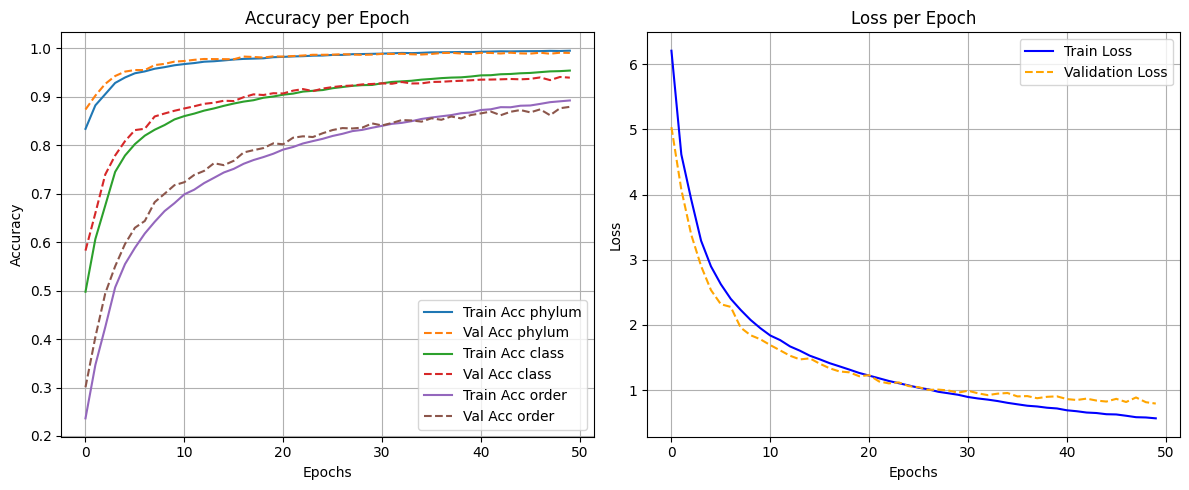

In [28]:
import matplotlib.pyplot as plt

# Create a figure with two subplots: one for accuracy and one for loss
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot all accuracies on the first subplot
for level in metrics["train_accuracies"].keys():
    axes[0].plot(metrics["train_accuracies"][level], label=f"Train Acc {level}")
    axes[0].plot(metrics["val_accuracies"][level], label=f"Val Acc {level}", linestyle="--")

axes[0].set_title("Accuracy per Epoch")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# Plot total loss on the second subplot
axes[1].plot(metrics["train_losses"], label="Train Loss", color="blue")
axes[1].plot(metrics["val_losses"], label="Validation Loss", color="orange", linestyle="--")

axes[1].set_title("Loss per Epoch")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

# Adjust layout and show plot
plt.tight_layout()
plt.show()
